# Telecom Churn Intelligence

This notebook supports a data-driven business proposal for a telecommunications operator. The objective is to identify churn risk patterns, build predictive models, and translate the model outputs into a targeted retention strategy based on the device lifecycle.

The analysis follows four stages: data loading and preparation, exploratory data analysis, machine learning model evaluation, and business impact estimation through risk deciles and ROI assumptions.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Path where the telecom folder is located
BASE_PATH = Path("/content/drive/MyDrive/Final Assignment/Final Assignment/telecom")

# File paths
client_path = BASE_PATH / "Client.csv"
record_path = BASE_PATH / "Record.csv"

# Validate that the files exist
print("Client exists:", client_path.exists())
print("Record exists:", record_path.exists())

# Load datasets
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

# Check table sizes
print("Client shape:", client.shape)
print("Record shape:", record.shape)

# View first rows
display(client.head())
display(record.head())

Mounted at /content/drive
Client exists: True
Record exists: True
Client shape: (100000, 50)
Record shape: (100000, 51)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


This code loads the data tables directly from the folder in my Google Drive.


In [2]:
# Merge tables
df = record.merge(client, on="Customer_ID", how="inner")

print("Merged dataset shape:", df.shape)
display(df.head())

# Review target variable
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True) * 100)
# (Churn: 1 Customer churned; Churn: 0 Customer did not churn)

Merged dataset shape: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,O,0.0,I,U,U,U,U,U,Y,434.0


churn
0    50438
1    49562
Name: count, dtype: int64
churn
0    50.438
1    49.562
Name: proportion, dtype: float64


The target distribution and missing values are analyzed.


Churn counts:
churn
0    50438
1    49562
Name: count, dtype: int64

Churn percentages:
churn
0    50.438
1    49.562
Name: proportion, dtype: float64


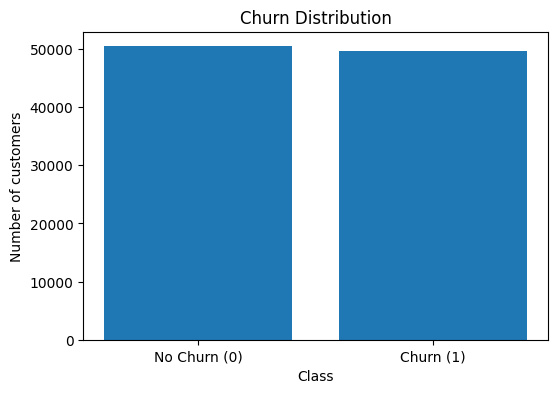

,missing_count,missing_percentage
numbcars,49366,49.366
dwllsize,38308,38.308
HHstatin,37923,37.923
ownrent,33706,33.706
dwlltype,31909,31.909
lor,30190,30.190
income,25436,25.436
adults,23019,23.019
infobase,22079,22.079
hnd_webcap,10189,10.189


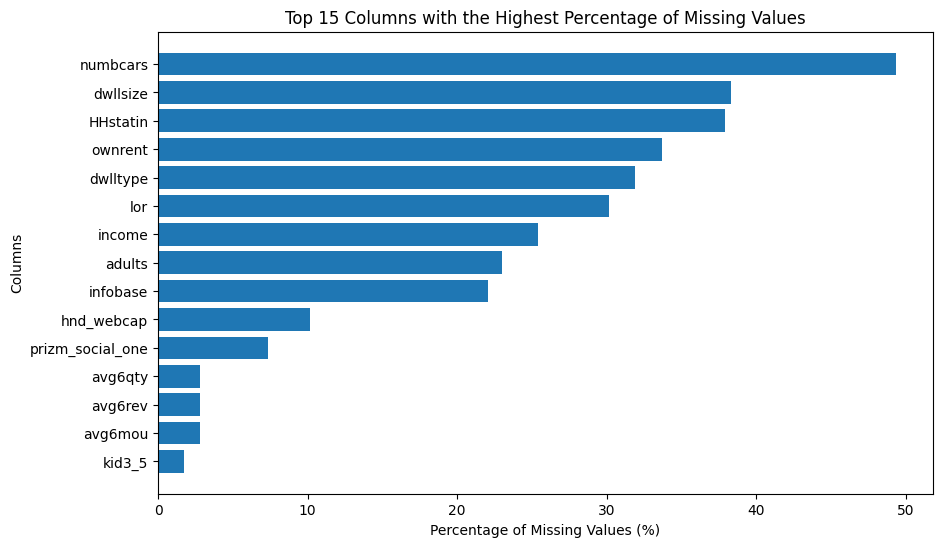

In [3]:
# =========================
# 1. Target distribution
# =========================

churn_counts = df["churn"].value_counts().sort_index()
churn_percentages = df["churn"].value_counts(normalize=True).sort_index() * 100

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(churn_percentages)

plt.figure(figsize=(6, 4))
plt.bar(["No Churn (0)", "Churn (1)"], churn_counts.values)
plt.title("Churn Distribution")
plt.xlabel("Class")
plt.ylabel("Number of customers")
plt.show()


# =========================
# 2. Missing values
# =========================

null_counts = df.isnull().sum()
null_percentages = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": null_counts,
    "missing_percentage": null_percentages
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_percentage", ascending=False)

display(missing_summary.head(20))


# =========================
# 3. Missing values chart
# =========================

top_missing = missing_summary.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index[::-1], top_missing["missing_percentage"].values[::-1])
plt.title("Top 15 Columns with the Highest Percentage of Missing Values")
plt.xlabel("Percentage of Missing Values (%)")
plt.ylabel("Columns")
plt.show()

Column cleaning and data typing are performed to review the unique values in the binary columns.


In [4]:
df_clean = df.copy()

def fill_columns_with_value(data, columns, value):
    for col in columns:
        if col in data.columns:
            data[col] = data[col].fillna(value)
        else:
            print(f"Warning: column not found -> {col}")

def fill_numeric_with_median(data, columns):
    for col in columns:
        if col in data.columns:
            data[col] = data[col].fillna(data[col].median())
        else:
            print(f"Warning: column not found -> {col}")


kid_cols = ['kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17']

num_low_null = [
    'rev_Mean', 'mou_Mean', 'da_Mean', 'ovrrev_Mean', 'totmrc_Mean',
    'ovrmou_Mean', 'vceovr_Mean', 'roam_Mean', 'datovr_Mean',
    'change_rev', 'change_mou', 'hnd_price', 'avg6rev', 'avg6qty', 'avg6mou'
]

high_null_cat = [
    'numbcars', 'dwllsize', 'HHstatin', 'ownrent', 'dwlltype', 'infobase',
    'prizm_social_one', 'hnd_webcap', 'area'
]

num_high_null = ['income', 'adults', 'lor']

# =========================
# 5. Remaining missing values
# =========================

# Categorical/binary variables with moderate missing values
remaining_cat_cols = ['creditcd', 'marital', 'ethnic']

for col in remaining_cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')


# Numeric binary variables with missing values: create a missing flag and then impute
remaining_binary_num_cols = ['rv', 'forgntvl', 'truck']

for col in remaining_binary_num_cols:
    df_clean[col + '_missing'] = df_clean[col].isnull().astype(int)
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


# Columns with only 1 missing value
# Numeric variables
one_null_numeric_cols = ['models', 'eqpdays', 'phones']

for col in one_null_numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())


# Categorical variables
one_null_cat_cols = ['refurb_new', 'dualband']

for col in one_null_cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')
# Apply cleaning
fill_columns_with_value(df_clean, kid_cols, 'Unknown')
fill_numeric_with_median(df_clean, num_low_null)
fill_columns_with_value(df_clean, high_null_cat, 'Unknown')

for col in num_high_null:
    if col in df_clean.columns:
        df_clean[col + '_missing'] = df_clean[col].isnull().astype(int)
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        print(f"Warning: column not found -> {col}")

In [5]:
remaining_nulls = df_clean.isnull().sum().sort_values(ascending=False)

print("Columns with remaining nulls:")
print(remaining_nulls[remaining_nulls > 0])

Columns with remaining nulls:
Series([], dtype: int64)


The remaining missing values were handled according to the nature of each feature. Categorical variables were filled with "Unknown" to maintain data neutrality. For binary numeric variables, imputation was performed using the most frequent value, and missing-value flags were added to preserve that contextual information. Finally, numeric variables with only one missing value were imputed using the median of the data vector.


In [6]:
key_vars = [
    'months', 'eqpdays', 'change_mou', 'change_rev', 'drop_vce_Mean',
    'custcare_Mean', 'totrev', 'avgrev', 'hnd_price', 'mou_Mean'
]

comparison = df_clean.groupby('churn')[key_vars].mean().T
comparison.columns = ['no_churn_mean', 'churn_mean']

comparison['diff_abs'] = comparison['churn_mean'] - comparison['no_churn_mean']

std_values = df_clean[key_vars].std()

comparison['standardized_diff'] = (
    comparison['diff_abs'] / std_values
).round(3)

comparison['diff_%'] = (
    comparison['diff_abs'] / comparison['no_churn_mean'] * 100
).round(1)

comparison = comparison.sort_values(
    'standardized_diff',
    key=lambda x: x.abs(),
    ascending=False
)

display(comparison)

,no_churn_mean,churn_mean,diff_abs,standardized_diff,diff_%
eqpdays,363.280503,421.089524,57.809021,0.225,15.9
hnd_price,108.042847,95.567449,-12.475398,-0.205,-11.5
mou_Mean,542.790083,482.674631,-60.115452,-0.115,-11.1
custcare_Mean,1.982599,1.595688,-0.386911,-0.073,-19.5
change_mou,-5.348090,-22.533162,-17.185072,-0.063,321.3
months,18.633074,19.038457,0.405383,0.042,2.2
drop_vce_Mean,6.090553,5.817222,-0.273331,-0.031,-4.5
avgrev,58.228573,57.593527,-0.635046,-0.018,-1.1
change_rev,-1.405570,-0.617074,0.788497,0.016,-56.1
totrev,1034.475849,1029.329041,-5.146808,-0.006,-0.5


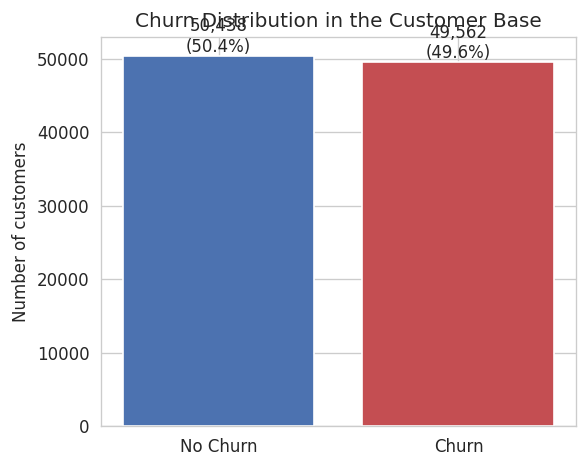

In [7]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
# --- Chart 1: Churn distribution
fig, ax = plt.subplots(figsize=(5,4))
counts = df_clean['churn'].value_counts().sort_index()
ax.bar(['No Churn', 'Churn'], counts.values, color=['#4C72B0', '#C44E52'])
ax.set_title('Churn Distribution in the Customer Base')
ax.set_ylabel('Number of customers')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

The target variable shows an almost balanced distribution, which ensures a statistically representative sample volume for both churned customers and active customers. This condition is optimal for model training and for the predictive model's generalization capacity.


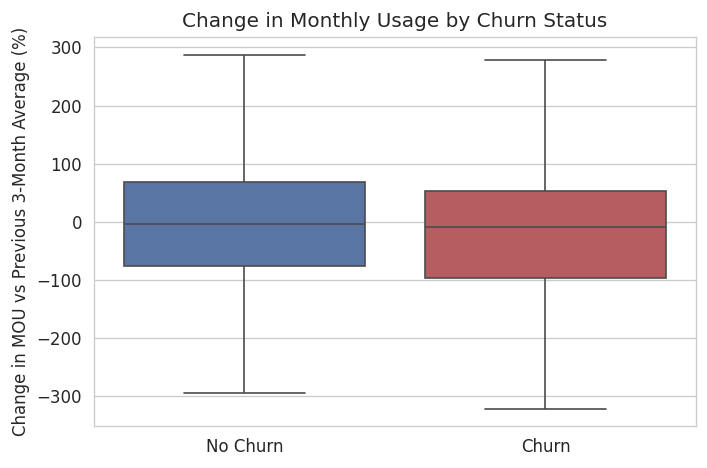

Median No Churn: -3.25
Median Churn: -8.75
Difference: -5.5


In [8]:
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(
    data=df_clean,
    x='churn',
    y='change_mou',
    ax=ax,
    palette=['#4C72B0','#C44E52'],
    showfliers=False
)

ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_title('Change in Monthly Usage by Churn Status')
ax.set_ylabel('Change in MOU vs Previous 3-Month Average (%)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('change_mou_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Numeric confirmation
df_clean.groupby('churn')['change_mou'].agg(
    count='count',
    mean='mean',
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
)
median_no_churn = df_clean[df_clean['churn'] == 0]['change_mou'].median()
median_churn = df_clean[df_clean['churn'] == 1]['change_mou'].median()

print("Median No Churn:", median_no_churn)
print("Median Churn:", median_churn)
print("Difference:", median_churn - median_no_churn)

The analysis reveals that the churn segment shows a slightly lower distribution in usage change, suggesting that a decrease in interaction is an early warning signal. However, given the high degree of overlap between both classes, this feature is not a definitive standalone predictor and must be combined with other variables within the predictive model.


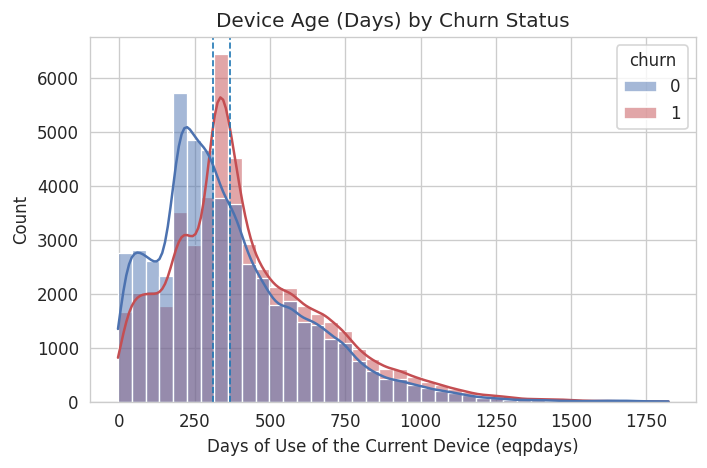

In [9]:
# --- Chart 3: Device age vs. churn ---
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(data=df_clean, x='eqpdays', hue='churn', bins=40, kde=True,
             palette=['#4C72B0','#C44E52'], alpha=0.5, ax=ax)
median_no_churn = df_clean[df_clean['churn'] == 0]['eqpdays'].median()
median_churn = df_clean[df_clean['churn'] == 1]['eqpdays'].median()
ax.axvline(median_no_churn, linestyle='--', linewidth=1)
ax.axvline(median_churn, linestyle='--', linewidth=1)
ax.set_title('Device Age (Days) by Churn Status')
ax.set_xlabel('Days of Use of the Current Device (eqpdays)')
plt.tight_layout()
plt.savefig('eqpdays_by_churn.png', dpi=150)
plt.show()

A positive correlation is observed between device age and churn risk, suggesting that handset upgrade campaigns may represent a highly relevant retention lever for this segment.


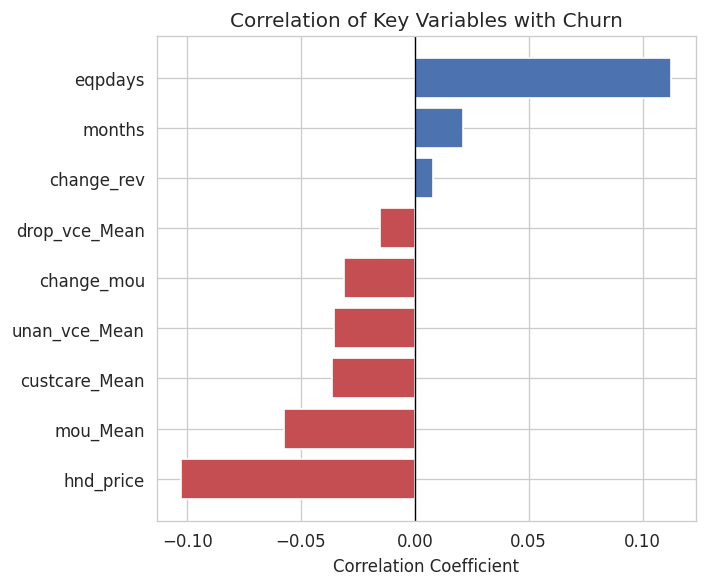

In [10]:
# --- Chart 4: Correlation matrix of top variables with churn ---
top_vars = ['change_mou','change_rev','eqpdays','custcare_Mean','mou_Mean',
            'hnd_price','months','unan_vce_Mean','drop_vce_Mean','churn']
corr = df_clean[top_vars].corr()['churn'].drop('churn').sort_values()

fig, ax = plt.subplots(figsize=(6,5))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_title('Correlation of Key Variables with Churn')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('correlation_churn.png', dpi=150)
plt.show()

Correlation is interpreted exclusively as an exploratory signal in the data, avoiding its use as evidence of causality. This methodological approach prevents bias by recognizing that statistical association between features does not imply that one directly determines the behavior of the other.


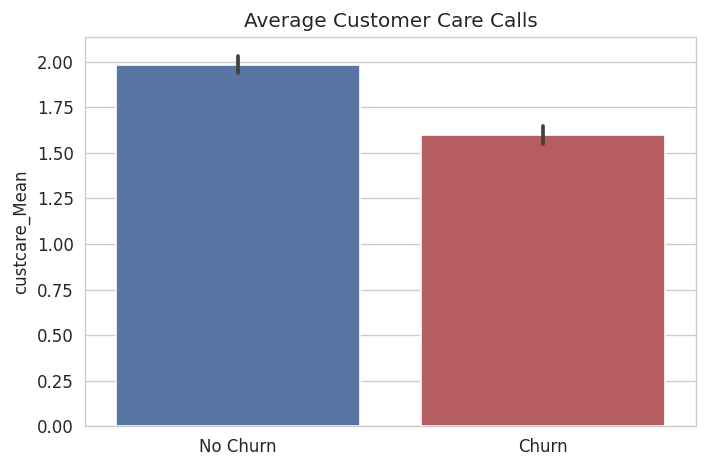

In [11]:
# --- Chart 5: Customer care calls vs. churn (dissatisfaction signal) ---
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=df, x='churn', y='custcare_Mean', ax=ax, palette=['#4C72B0','#C44E52'],
            errorbar=('ci', 95))
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_title('Average Customer Care Calls')
ax.set_ylabel('custcare_Mean')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('custcare_by_churn.png', dpi=150)
plt.show()

To predict the probability of churn, a predictive model was implemented with an initial pipeline that separated the features from the target and automatically classified the variables into quantitative and qualitative groups. Next, the dataset was split using an 80/20 ratio for training and validation. This split was performed in a stratified manner, ensuring that both the train and test sets maintained the same proportion of retained and churned customers, thereby mitigating bias in the model evaluation.


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# =========================
# 1. Separate features and target
# =========================
TARGET_COL = "churn"
ID_COLS = ["Customer_ID"]

feature_df = df_clean.drop(columns=ID_COLS + [TARGET_COL])
target = df_clean[TARGET_COL]

num_cols = feature_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = feature_df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Force a uniform string type for categorical variables (prevents TypeError due to mixed str/float values in OneHotEncoder)
feature_df[cat_cols] = feature_df[cat_cols].astype(str).replace('nan', 'Unknown')

print(f"Numeric variables: {len(num_cols)}")
print(f"Categorical variables: {len(cat_cols)}")

# =========================
# 2. Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target, test_size=0.2, random_state=7, stratify=target
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# =========================
# 3. Preprocessing blocks
# =========================
scaled_numeric_block = Pipeline([
    ("fill_median", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

raw_numeric_block = Pipeline([
    ("fill_median", SimpleImputer(strategy="median")),
])

categorical_block = Pipeline([
    ("fill_unknown", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

prep_for_linear = ColumnTransformer([
    ("numeric", scaled_numeric_block, num_cols),
    ("categorical", categorical_block, cat_cols),
])

prep_for_trees = ColumnTransformer([
    ("numeric", raw_numeric_block, num_cols),
    ("categorical", categorical_block, cat_cols),
])

# =========================
# 4. Candidate models
# =========================
candidate_models = {
    "Logistic Regression": Pipeline([
        ("prep", prep_for_linear),
        ("clf", LogisticRegression(max_iter=1000, random_state=7)),
    ]),
    "Random Forest": Pipeline([
        ("prep", prep_for_trees),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=20,
            random_state=7, n_jobs=-1,
        )),
    ]),
}

# =========================
# 5. Train and evaluate each model
# =========================
def score_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    probs = pipeline.predict_proba(X_te)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, preds),
        "precision": precision_score(y_te, preds, zero_division=0),
        "recall": recall_score(y_te, preds, zero_division=0),
        "f1_score": f1_score(y_te, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_te, probs),
    }
    return metrics, pipeline

scoreboard = []
fitted_pipelines = {}

for name, pipe in candidate_models.items():
    metrics, fitted = score_model(name, pipe, X_train, y_train, X_test, y_test)
    scoreboard.append(metrics)
    fitted_pipelines[name] = fitted

results = pd.DataFrame(scoreboard).set_index("model").round(3)
display(results)

# =========================
# 6. Select the best model by ROC-AUC
# =========================
best_model_name = results["roc_auc"].idxmax()
best_pipeline = fitted_pipelines[best_model_name]
print(f"\nBest model by ROC-AUC: {best_model_name}")

# =========================
# 7. Feature importance (only if the best model is a tree-based model)
# =========================
if best_model_name == "Random Forest":
    feature_names = best_pipeline.named_steps["prep"].get_feature_names_out()
    importances = pd.Series(
        best_pipeline.named_steps["clf"].feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    print("\nTop 15 most predictive variables:")
    print(importances.head(15))

Numeric variables: 82
Categorical variables: 22
Train: (80000, 104) | Test: (20000, 104)


,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
Logistic Regression,0.596,0.593,0.594,0.593,0.633
Random Forest,0.615,0.606,0.636,0.621,0.666



Best model by ROC-AUC: Random Forest

Top 15 most predictive variables:
numeric__eqpdays                0.106586
numeric__months                 0.084614
numeric__change_mou             0.035388
numeric__mou_Mean               0.030966
numeric__hnd_price              0.030228
numeric__totmrc_Mean            0.027822
numeric__adjrev                 0.026167
numeric__totrev                 0.024474
numeric__avg3mou                0.020076
numeric__totcalls               0.017619
numeric__adjqty                 0.017596
numeric__avgqty                 0.017274
numeric__avg3qty                0.016947
categorical__hnd_webcap_WCMB    0.016316
numeric__totmou                 0.015629
dtype: float64


In [13]:
# =========================
# 8. Business evaluation table: churn risk deciles
# =========================
# Use the same split defined previously
idx_test = X_test.index

# Retrain the best pipeline
best_pipeline.fit(X_train, y_train)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

business_df = pd.DataFrame({
    "actual_churn": y_test.values,
    "churn_probability": y_proba_best,
    "revenue_value": df_clean.loc[idx_test, "avgrev"].values  # avgrev = actual average monthly revenue
})

business_df = business_df.sort_values("churn_probability", ascending=False).reset_index(drop=True)
business_df["risk_decile"] = pd.qcut(
    business_df["churn_probability"].rank(method="first", ascending=False),
    10,
    labels=range(1, 11)
)

base_churn_rate = business_df["actual_churn"].mean() * 100
total_churners = business_df["actual_churn"].sum()

decile_table = business_df.groupby("risk_decile", observed=False).agg(
    n_customers=("actual_churn", "size"),
    actual_churners=("actual_churn", "sum"),
    actual_churn_rate=("actual_churn", "mean"),
    monthly_revenue_at_risk=("revenue_value", "sum"),
    avg_churn_probability=("churn_probability", "mean")
).reset_index()

decile_table["actual_churn_rate"] = (decile_table["actual_churn_rate"] * 100).round(1)
decile_table["avg_churn_probability"] = (decile_table["avg_churn_probability"] * 100).round(1)
decile_table["monthly_revenue_at_risk"] = decile_table["monthly_revenue_at_risk"].round(0)
decile_table["cumulative_churners_captured_%"] = (
    decile_table["actual_churners"].cumsum() / total_churners * 100
).round(1)
decile_table["lift_vs_baseline"] = (
    decile_table["actual_churn_rate"] / base_churn_rate
).round(2)

display(decile_table)

,risk_decile,n_customers,actual_churners,actual_churn_rate,monthly_revenue_at_risk,avg_churn_probability,cumulative_churners_captured_%,lift_vs_baseline
0,1,2000,1470,73.5,104538.0,64.0,14.8,1.48
1,2,2000,1288,64.4,102621.0,57.6,27.8,1.30
2,3,2000,1207,60.4,103174.0,55.1,40.0,1.22
3,4,2000,1109,55.4,105572.0,53.2,51.2,1.12
4,5,2000,1041,52.0,109398.0,51.3,61.7,1.05
5,6,2000,969,48.4,113903.0,49.4,71.5,0.98
6,7,2000,922,46.1,123348.0,47.2,80.8,0.93
7,8,2000,825,41.2,140625.0,44.4,89.1,0.83
8,9,2000,644,32.2,144536.0,40.7,95.6,0.65
9,10,2000,437,21.8,112935.0,32.5,100.0,0.44


In [14]:
active_base = 1_000_000
campaign_customers = 40_000
campaign_cost = 70
annual_arpu = 600
save_rate = 0.35

total_campaign_cost = campaign_customers * campaign_cost
gross_protected_revenue = campaign_customers * save_rate * annual_arpu
net_impact = gross_protected_revenue - total_campaign_cost
net_roi = net_impact / total_campaign_cost

print("Campaign cost:", total_campaign_cost)
print("Gross protected revenue:", gross_protected_revenue)
print("Net impact:", net_impact)
print("Net ROI:", round(net_roi, 2))

Campaign cost: 2800000
Gross protected revenue: 8400000.0
Net impact: 5600000.0
Net ROI: 2.0


Through the risk-decile segmentation generated by the model, the upper groups are observed to capture an actual churn rate that exceeds the overall average. This efficient stratification of the database enables targeted loyalty campaigns, maximizing ROI by concentrating mitigation efforts on a limited but high-priority subset.


## Final Business Conclusion

The Random Forest model was selected because it achieved stronger Recall and ROC-AUC performance than the Logistic Regression baseline. The risk-decile segmentation translates the model output into an operational retention strategy: prioritize the highest-risk customers first, validate the campaign through a controlled pilot, and scale the DLIS System based on observed ROI.

This connects the analytical evidence to a concrete business proposal: reduce inefficient mass retention spending, protect customer Lifetime Value, and operationalize churn prevention through CRM-triggered campaigns around the device renewal window.

